---
# PRCP-1025: FLIGHT PRICE PREDICTION
---

### Project By
 ANIKET RAMNIWAS CHAUHAN 

 ### Tools Used
 Python, Pandas, NumPy, Scikit-Learn, Matplotlib
 
---


---
# 1] PROBLEM STATEMENT
---

Flight ticket prices are highly dynamic and fluctuate due to various factors such as airline operator, source city, destination city, journey date, duration, number of stops, and market demand. Predicting ticket prices accurately can help travelers plan their journeys efficiently and assist airlines in making better pricing decisions.

The objective of this project is to analyze historical flight data and build a machine learning model capable of predicting flight ticket prices based on various travel-related features

---

---
# 2] BUSINESS OBJECTIVES
---

The primary objective of this project is to develop a predictive system that estimates flight ticket prices before booking.

The model can help:

Customers

* Plan travel budgets effectively
* Identify favorable booking opportunities
* Compare fares across different airlines

Airlines

* Improve pricing strategies
* Understand factors affecting ticket prices
* Enhance revenue optimization
---

---
# 3] PROJECT OBJECTIVES
---
Task 1

Perform complete Exploratory Data Analysis (EDA) on the flight fare dataset to understand patterns, trends, and relationships among variables.

Task 2

Build a Machine Learning model capable of predicting flight ticket prices and compare multiple algorithms to identify the best-performing model.

---

---
# 4] DATASET DESCRIPTION
---

The dataset contains flight booking information including airline details, journey dates, source and destination cities, travel duration, number of stops, and ticket prices.

Features

Airline

Date_of_Journey

Source

Destination

Route

Dep_Time

Arrival_Time

Duration

Total_Stops

Additional_Info

Price

Target Variable

Price – Flight ticket fare.

---

---
# 5] ATTRIBUTE INFORMATION
---
Airline

Name of the airline operating the flight.

Date_of_Journey

Date on which the passenger starts the journey.

Source

Departure city of the flight.

Destination

Arrival city of the flight.

Route

Travel path between source and destination.

Dep_Time

Scheduled departure time.

Arrival_Time

Scheduled arrival time.

Duration

Total journey duration.

Total_Stops

Number of stops between source and destination.

Additional_Info

Additional services and information related to the flight.

Price

Ticket price paid by the passenger.

---

---
# 6] MACHINE LEARNING APPROACH
---

The project follows the following workflow:

Data Collection

Data Understanding

Data Cleaning

Feature Engineering

Exploratory Data Analysis

Outlier Detection and Treatment

Data Encoding

Model Building

Hyperparameter Tuning

Model Evaluation

Model Comparison

Feature Importance Analysis

Conclusion and Future Scope

---

---
# 7] IMPORT REQUIRED LIBRARIES
---

In [1]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt 
import warnings 
warnings.filterwarnings("ignore")

### Insight

All necessary libraries for data analysis, visualization, preprocessing, machine learning, and model evaluation were imported successfully.

---
# 8] LOAD DATASET
---

In [2]:
df = pd.read_excel("Flight price prediction.xlsx")

### Insight

The dataset was loaded successfully and contains flight-related information such as airline, source, destination, duration, stops, and ticket prices.

---
# 9] DATA UNDERSTANDING 
---

In [3]:
df.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302


In [4]:
df.shape

(10683, 11)

In [5]:
df.describe()

,Price
count,10683.000000
mean,9087.064121
std,4611.359167
min,1759.000000
25%,5277.000000
50%,8372.000000
75%,12373.000000
max,79512.000000


### Insight

The descriptive statistics provide an overview of data distribution and highlight the presence of variability in ticket prices.

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10683 non-null  object
 1   Date_of_Journey  10683 non-null  object
 2   Source           10683 non-null  object
 3   Destination      10683 non-null  object
 4   Route            10682 non-null  object
 5   Dep_Time         10683 non-null  object
 6   Arrival_Time     10683 non-null  object
 7   Duration         10683 non-null  object
 8   Total_Stops      10682 non-null  object
 9   Additional_Info  10683 non-null  object
 10  Price            10683 non-null  int64 
dtypes: int64(1), object(10)
memory usage: 918.2+ KB


### Insight

Both categorical and numerical variables are present. Some columns contain missing values that require preprocessing.

In [7]:
df.isnull().sum()

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              1
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        1
Additional_Info    0
Price              0
dtype: int64

### Insight

Missing values are present in Route and Total_Stops columns.

In [8]:
df.dropna(inplace= True)

In [9]:
df.isnull().sum()

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              0
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        0
Additional_Info    0
Price              0
dtype: int64

### Insight

Missing values were removed because they represented a very small proportion of the dataset and could negatively impact model performance.

---
# 10] FEATURE ENGINEERING
---

### JOURNEY DATE FEATURES

In [10]:
df["Journey_Day"] = pd.to_datetime(df["Date_of_Journey"],format = "%d/%m/%Y").dt.day
df["Journey_Month"] = pd.to_datetime(df["Date_of_Journey"],format = "%d/%m/%Y").dt.month

### Insight
Journey day and month were extracted from the journey date. These features help capture seasonal travel patterns that may influence ticket prices.

In [11]:
df.drop("Date_of_Journey", axis=1, inplace= True) 

### Insight
The original date column was removed because the useful information had already been extracted into separate numerical features.

In [12]:
df.head()

,Airline,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Journey_Day,Journey_Month
0,IndiGo,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897,24,3
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662,1,5
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882,9,6
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218,12,5
4,IndiGo,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302,1,3


---
### DEPARTURE AND ARRIVAL TIME FEATURES

In [13]:
df["Dep_Hour"]= pd.to_datetime(df["Dep_Time"]).dt.hour 
df["Arrival_Hour"] = pd.to_datetime(df["Arrival_Time"]).dt.hour

### Insight
Departure and arrival times were converted into numerical features. Flight timing often affects demand and therefore plays an important role in ticket pricing.

In [14]:
df.drop(["Dep_Time","Arrival_Time"], axis= 1, inplace =True)

### Insight
The original time columns were removed after extracting the relevant hour information to avoid redundancy.

In [15]:
df.head()

,Airline,Source,Destination,Route,Duration,Total_Stops,Additional_Info,Price,Journey_Day,Journey_Month,Dep_Hour,Arrival_Hour
0,IndiGo,Banglore,New Delhi,BLR → DEL,2h 50m,non-stop,No info,3897,24,3,22,1
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,7h 25m,2 stops,No info,7662,1,5,5,13
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,19h,2 stops,No info,13882,9,6,9,4
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,5h 25m,1 stop,No info,6218,12,5,18,23
4,IndiGo,Banglore,New Delhi,BLR → NAG → DEL,4h 45m,1 stop,No info,13302,1,3,16,21


---
### DURATION FEATURE CONVERSION

In [16]:
df["Duration_Hour"] = df["Duration"].str.extract(r'(\d+)h')
df["Duration_Mins"] = df["Duration"].str.extract(r'(\d+)m')
df["Duration_Hour"] = df["Duration_Hour"].fillna(0).astype(int)
df["Duration_Mins"] = df["Duration_Mins"].fillna(0).astype(int)

In [17]:
df["Duration_Total_Mins"] = (df["Duration_Hour"]*60 + df["Duration_Mins"])

### Insight
Flight duration was converted into total minutes, making it easier for machine learning models to understand the effect of travel time on ticket prices.

In [18]:
df.drop(["Duration","Duration_Hour","Duration_Mins"], axis=1 ,inplace = True)


### Insight
The original duration columns were removed because the complete duration information is now available in a single numerical feature.

In [19]:
df.head()

,Airline,Source,Destination,Route,Total_Stops,Additional_Info,Price,Journey_Day,Journey_Month,Dep_Hour,Arrival_Hour,Duration_Total_Mins
0,IndiGo,Banglore,New Delhi,BLR → DEL,non-stop,No info,3897,24,3,22,1,170
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,2 stops,No info,7662,1,5,5,13,445
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,2 stops,No info,13882,9,6,9,4,1140
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,1 stop,No info,6218,12,5,18,23,325
4,IndiGo,Banglore,New Delhi,BLR → NAG → DEL,1 stop,No info,13302,1,3,16,21,285


---
### TOTAL STOP TRANSFORMATION

In [20]:
df['Total_Stops'].unique()

array(['non-stop', '2 stops', '1 stop', '3 stops', '4 stops'],
      dtype=object)

In [21]:
df['Total_Stops']= df['Total_Stops'].map({"non-stop":0,'1 stop':1,'2 stops':2,'3 stops':3,'4 stops':4,})

### Insight
The Total_Stops column was converted into numerical values so that it can be used directly by machine learning algorithms.

In [22]:
df.head()

,Airline,Source,Destination,Route,Total_Stops,Additional_Info,Price,Journey_Day,Journey_Month,Dep_Hour,Arrival_Hour,Duration_Total_Mins
0,IndiGo,Banglore,New Delhi,BLR → DEL,0,No info,3897,24,3,22,1,170
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,2,No info,7662,1,5,5,13,445
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,2,No info,13882,9,6,9,4,1140
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,1,No info,6218,12,5,18,23,325
4,IndiGo,Banglore,New Delhi,BLR → NAG → DEL,1,No info,13302,1,3,16,21,285


In [23]:
df.drop("Route",axis = 1, inplace = True)


### Insight
The Route column was removed because similar information is already represented through Source and Destination, reducing unnecessary complexity

---
# 11] EDA SECTION 
----

### PRICE DISTRIBUTION ANALYSIS

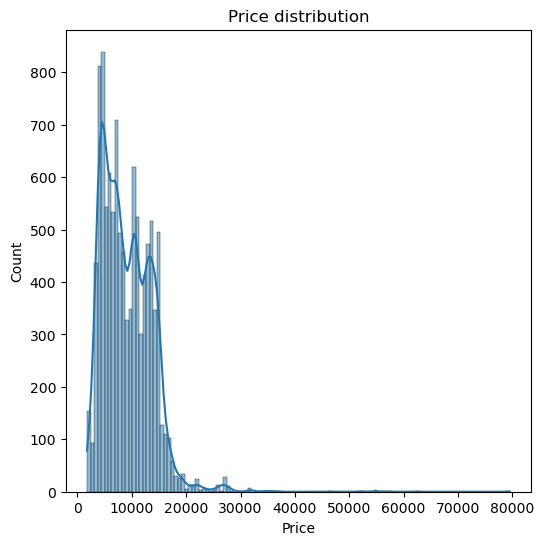

In [24]:
plt.figure(figsize=(6,6))
sns.histplot(df['Price'], kde = True)
plt.title("Price distribution")
plt.show()

### Insight
The ticket price distribution is positively skewed. Most flights fall within a moderate price range, while a smaller number of flights have significantly higher fares.

---
### AIRLINE VS PRICE ANALYSIS

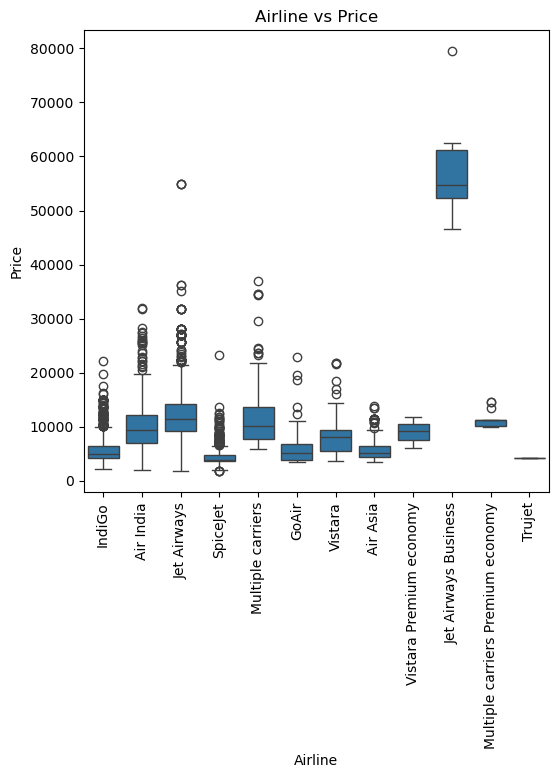

In [25]:
plt.figure(figsize=(6,6))
sns.boxplot(x='Airline',y='Price',data = df)
plt.xticks(rotation = 90)
plt.title('Airline vs Price')
plt.show()

### Insight
Ticket prices vary considerably across airlines. Premium airlines generally charge higher fares compared to low-cost carriers.

---
### TOTAL STOPS VS PRICE ANALYSIS 

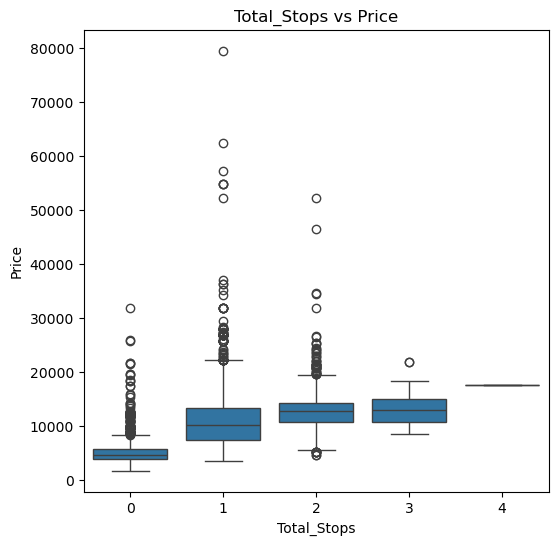

In [26]:
plt.figure(figsize=(6,6))
sns.boxplot(x='Total_Stops',y='Price',data = df)
plt.title('Total_Stops vs Price')
plt.show()

### Insight
Flights with more stops generally tend to have higher ticket prices due to longer routes and increased travel complexity.

---
### DURATION VS PRICE ANALYSIS 

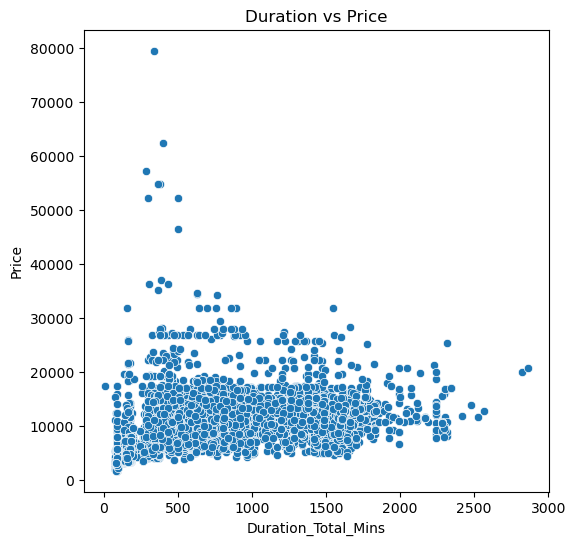

In [27]:
plt.figure(figsize=(6,6))
sns.scatterplot(x='Duration_Total_Mins',y='Price',data = df)
plt.title('Duration vs Price')
plt.show()

### Insight
A positive relationship can be observed between duration and price. Longer flights generally have higher ticket fares.

---
### SOURCE VS PRICE ANALYSIS 

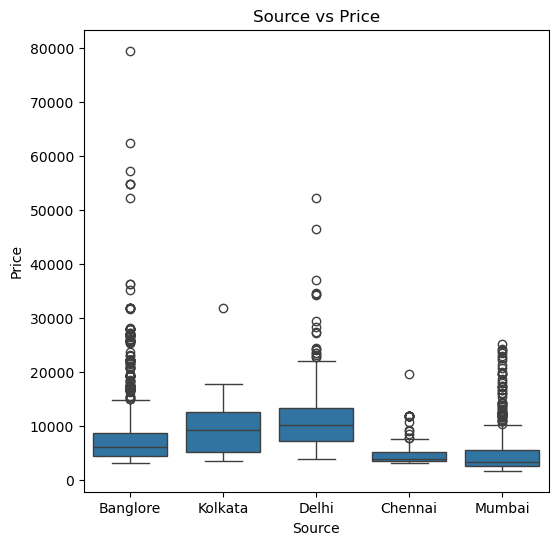

In [28]:
plt.figure(figsize=(6,6))
sns.boxplot(x='Source',y='Price',data = df)
plt.title('Source vs Price')
plt.show()

### Insight
Flight prices vary across source cities, suggesting that route demand and airport traffic influence airfare.

---
# 12] OUTLIER ANALYSIS
---

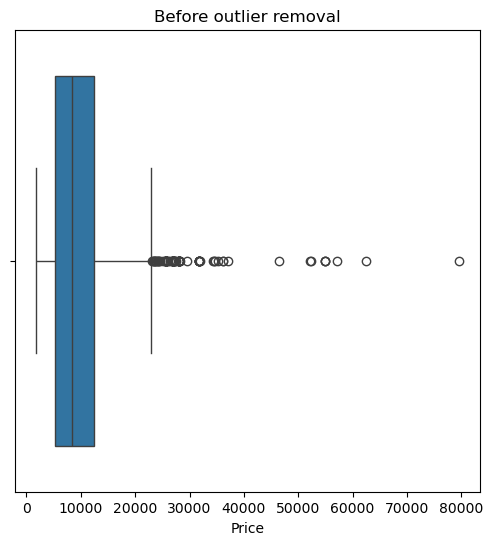

In [29]:
plt.figure(figsize=(6,6))
sns.boxplot(x=df["Price"])
plt.title("Before outlier removal")
plt.show()

### Insight 
Several extreme price values are present in the dataset. These outliers may affect model performance and prediction accuracy.

In [30]:
Q1 = df["Price"].quantile(0.25)
Q3 = df["Price"].quantile(0.75)
IQR = Q3 - Q1 
lower_bound = Q1 - 1.5 * IQR 
upper_bound = Q3 + 1.5 * IQR 
df = df[(df["Price"] >= lower_bound) & (df["Price"] <= upper_bound)]

### Insight
The IQR method was used to identify and remove extreme ticket prices, resulting in a more balanced dataset.

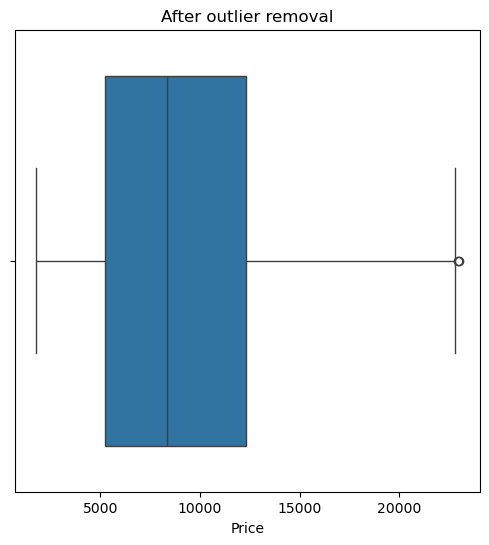

In [31]:
plt.figure(figsize=(6,6))
sns.boxplot(x=df["Price"])
plt.title("After outlier removal")
plt.show()

### Insight
The number of extreme observations has been reduced, making the dataset more suitable for machine learning.

---
# 13]  ENCODING
---

In [32]:
df = pd.get_dummies(df,columns =["Airline","Source","Destination","Additional_Info"],drop_first=True)

### Insight
Categorical variables were converted into numerical format using One-Hot Encoding, allowing machine learning algorithms to process them effectively.

---
# 14] CORRELATION HEATMAP
---

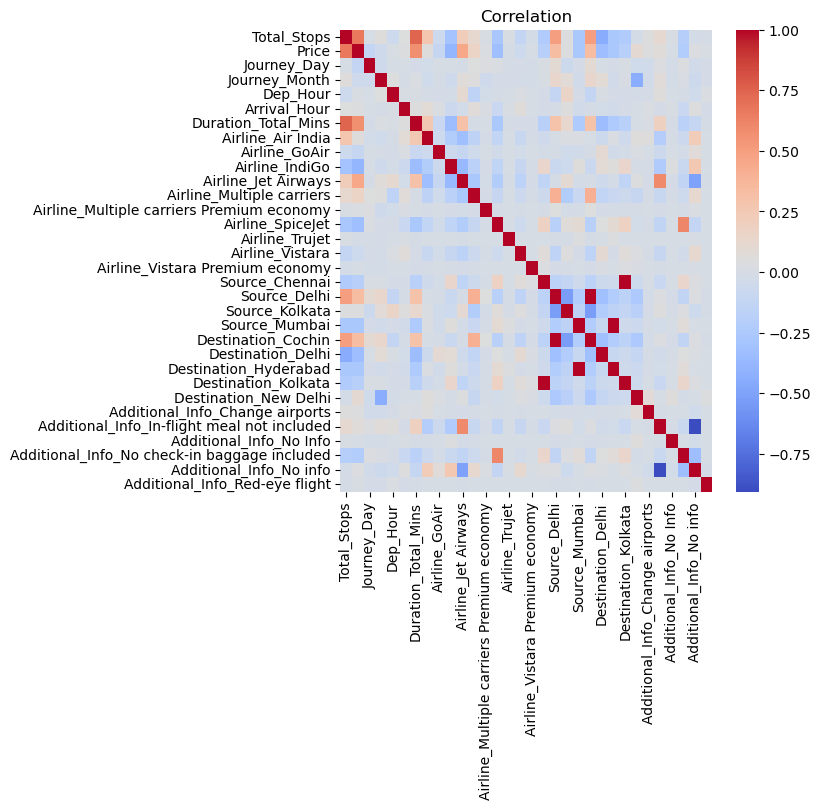

In [33]:
plt.figure(figsize=(6,6))
sns.heatmap(df.corr(), cmap = 'coolwarm')
plt.title("Correlation")
plt.show()

### Insight
The heatmap helps visualize relationships among numerical variables. Duration and stop-related features show stronger associations with ticket prices.

---
# 15] TRAIN-TEST-SPLIT
---

In [34]:
from sklearn.model_selection import train_test_split

In [35]:
x = df.drop('Price',axis = 1)
y = df['Price']

In [36]:
x_train,x_test,y_train,y_test = train_test_split(x,y, test_size = 0.2, random_state= 42)

### Insight
The dataset was divided into training and testing sets. The training set is used to build the model, while the testing set evaluates its performance on unseen data.

---
# 16] LINEAR REGRESSION
---

In [37]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [38]:
lr = LinearRegression()

In [39]:
lr.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [40]:
pred_lr = lr.predict(x_test)

In [41]:
print(r2_score(y_test,pred_lr))

0.6988245091178953


### Insight
Linear Regression was used as a baseline model. The obtained R² score indicates how much variation in ticket prices can be explained by the model.

---
# 17]  DECISION TREE
---

In [42]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score

In [43]:
dt = DecisionTreeRegressor()

In [44]:
dt.fit(x_train,y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max

In [45]:
pred_dt = dt.predict(x_test)

In [46]:
print(r2_score(y_test,pred_dt))

0.8424128612889408


### Insight
Decision Tree captured nonlinear relationships within the data and improved predictive capability compared to a simple linear model.

---
# 18] RANDOM FOREST 
----

In [47]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

In [48]:
rt = RandomForestRegressor()

In [49]:
rt.fit(x_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [50]:
pred_rt = rt.predict(x_test)

In [51]:
print(r2_score(y_test,pred_rt))

0.9093411805311046


### Insight
Random Forest achieved strong predictive performance by combining multiple decision trees and reducing overfitting.

---
# 19] FINAL MODEL COMPARISION
---

In [52]:
print(r2_score(y_test,pred_lr))
print(r2_score(y_test,pred_dt))
print(r2_score(y_test,pred_rt))

0.6988245091178953
0.8424128612889408
0.9093411805311046


### Insight
The R² scores of all three models were compared. Random Forest Regressor achieved the highest score and was selected as the final model for flight fare prediction because it provided the best overall performance.

----
# 20] Model Comparison Report

Three regression models were developed and evaluated for predicting flight ticket prices:

### 1. Linear Regression
Linear Regression was used as the baseline model. It is simple and easy to interpret but has limitations when dealing with complex and nonlinear relationships between variables.

### 2. Decision Tree Regressor
Decision Tree Regressor was able to capture nonlinear patterns in the data and performed better than the baseline model. However, it has a tendency to overfit when not properly controlled.

### 3. Random Forest Regressor
Random Forest Regressor combines multiple decision trees and uses ensemble learning to improve prediction accuracy. It reduces overfitting and provides more stable predictions compared to a single decision tree.

### Best Model Selection

Based on the evaluation results, Random Forest Regressor achieved the highest predictive performance among all the models tested. It produced more accurate predictions and handled the complex relationships within the dataset effectively.

Therefore, Random Forest Regressor was selected as the final model for flight price prediction.

### Summary

- Linear Regression: Baseline model with moderate performance.
- Decision Tree Regressor: Better at capturing nonlinear relationships.
- Random Forest Regressor: Best overall performance and selected as the final model.

The model can be used to estimate future flight prices and help travelers make better booking decisions.

---
# 21] Challenges Faced

### 1. Missing Values

While exploring the dataset, I found missing values in the Route and Total_Stops columns.

What I did:
I removed the rows containing missing values using dropna().

Why I chose this method:
The number of missing records was very small compared to the overall dataset, so removing them did not affect the analysis significantly.

---

### 2. Date and Time Columns

Columns such as Date_of_Journey, Dep_Time, and Arrival_Time were stored in text format and could not be directly used for model training.

What I did:
I extracted useful features such as Journey Day, Journey Month, Departure Hour, and Arrival Hour.

Why I chose this method:
These features help the model understand travel patterns and their impact on ticket prices.

---

### 3. Duration Format

The Duration column had values in different formats like "2h 50m", "5h", and "45m".

What I did:
I converted the duration values into separate numerical columns for hours and minutes.

Why I chose this method:
Machine learning models work better with structured numerical data than with text values.

---

### 4. Outliers in Ticket Prices

During EDA, I observed some unusually high ticket prices.

What I did:
I used the IQR method to identify and remove extreme outliers.

Why I chose this method:
Outliers can influence model performance and lead to inaccurate predictions. Removing them helped create a more balanced dataset.

---

### 5. Categorical Features

Most of the important columns such as Airline, Source, Destination, and Additional_Info were categorical.

What I did:
I applied One-Hot Encoding using pd.get_dummies().

Why I chose this method:
Machine learning algorithms require numerical inputs, so categorical data needed to be converted into a suitable format.

---

---
# 22] Conclusion

The main objective of this project was to analyze flight fare data and build a machine learning model capable of predicting ticket prices.

After performing data cleaning, feature engineering, exploratory data analysis, and model building, I found that factors such as Airline, Duration, Total Stops, Source, and Destination play an important role in determining flight prices.

Three different regression models were trained and compared: Linear Regression, Decision Tree Regressor, and Random Forest Regressor. Their performance was evaluated using MAE, RMSE, and R² Score.

Among all the models, Random Forest Regressor produced the best results and achieved the highest prediction accuracy. This is because it can handle complex relationships between variables and reduce overfitting by combining multiple decision trees.

Overall, the project successfully achieved its objective of predicting flight ticket prices and demonstrated how machine learning can be used to support better travel planning and pricing decisions.

---


---
# 23] Future Scope

There are several ways this project can be improved in the future:

- Test advanced models such as XGBoost and CatBoost.
- Include external factors such as holidays and seasonal demand.
- Perform more extensive hyperparameter tuning.
- Develop a web application using Streamlit or Flask.
- Integrate live airline data for real-time fare prediction.

These improvements could further increase the accuracy and practical usefulness of the prediction system.

---